In [2]:

%load_ext autoreload
%autoreload 2
%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

/home/connorlab/miniconda3/envs/neural_analysis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-05-08 12:04:46.723098: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [6]:
significant_results = pd.read_pickle('/home/connorlab/Documents/GitHub/Julie/Cortana/analysis_results/Zombies_marg_ols_on_single_neurons.pkl')
significant_results = significant_results[significant_results['p_value'] < 0.01]
significant_results = significant_results[significant_results['R-squared'] > 0.5]
print(significant_results.shape)
print(significant_results['NeuronID'].nunique())


(222, 7)
130


In [7]:
significant_results

,NeuronID,Behavior,Source_Monkey,Model,R-squared,coef,p_value
12406,AMG_2023-10-09_3_Channel.C_011,AgonismTo,110E,ols,0.696391,0.210522,0.009973
12446,AMG_2023-10-09_3_Channel.C_028,AgonismTo,151J,ols,0.696506,0.747766,0.009961
10310,ER_2023-11-22_2_Channel.C_028,SubmissionFrom,67G,ols,0.696610,-0.474178,0.009950
6686,AMG_2023-10-09_3_Channel.C_013,SubmissionTo,151J,ols,0.697235,0.805146,0.009885
13345,ER_2023-11-22_4_Channel.C_020,AgonismTo,87J,ols,0.697531,-0.596510,0.009855
...,...,...,...,...,...,...,...
2836,Unknown_2023-12-18_3_Channel.C_003,AffiliationTo,69X,ols,0.912103,0.494895,0.000220
14956,AMG_2023-10-04_2_Channel.C_020_Unit 2,AgonismFrom,87J,ols,0.924980,0.815945,0.000136
5707,Unknown_2023-12-18_3_Channel.C_003,AffiliationFrom,69X,ols,0.925018,0.498386,0.000136
8458,ER_2023-12-14_4_Channel.C_004,SubmissionTo,87J,ols,0.925692,0.329421,0.000132


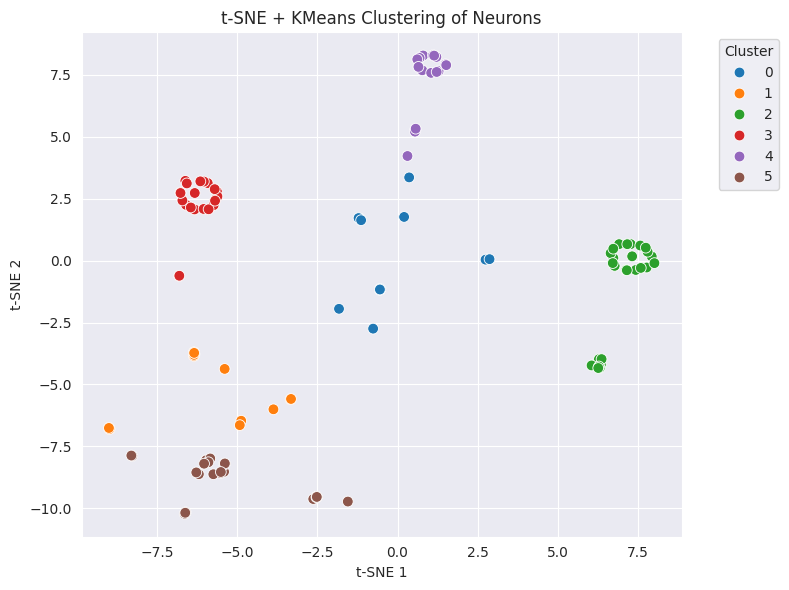

In [13]:
df= significant_results
# 뉴런별로 Behavior마다 R²가 가장 높은 회귀 하나만 선택
best_coef_df = (
    df[df['p_value'] < 0.05]
    .sort_values('R-squared', ascending=False)
    .drop_duplicates(subset=['NeuronID', 'Behavior'])
)

pivot_df = best_coef_df.pivot(index='NeuronID', columns='Behavior', values='R-squared').fillna(0)

# Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pivot_df)

# t-sne
tsne = TSNE(n_components=2, perplexity=20, random_state=42, init='pca')
tsne_coords = tsne.fit_transform(scaled_data)

# KMeans clustering
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(tsne_coords)

# add cluster colors to t-sne plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=tsne_coords[:, 0], y=tsne_coords[:, 1], hue=cluster_labels, palette='tab10', s=60)
plt.title("t-SNE + KMeans Clustering of Neurons")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


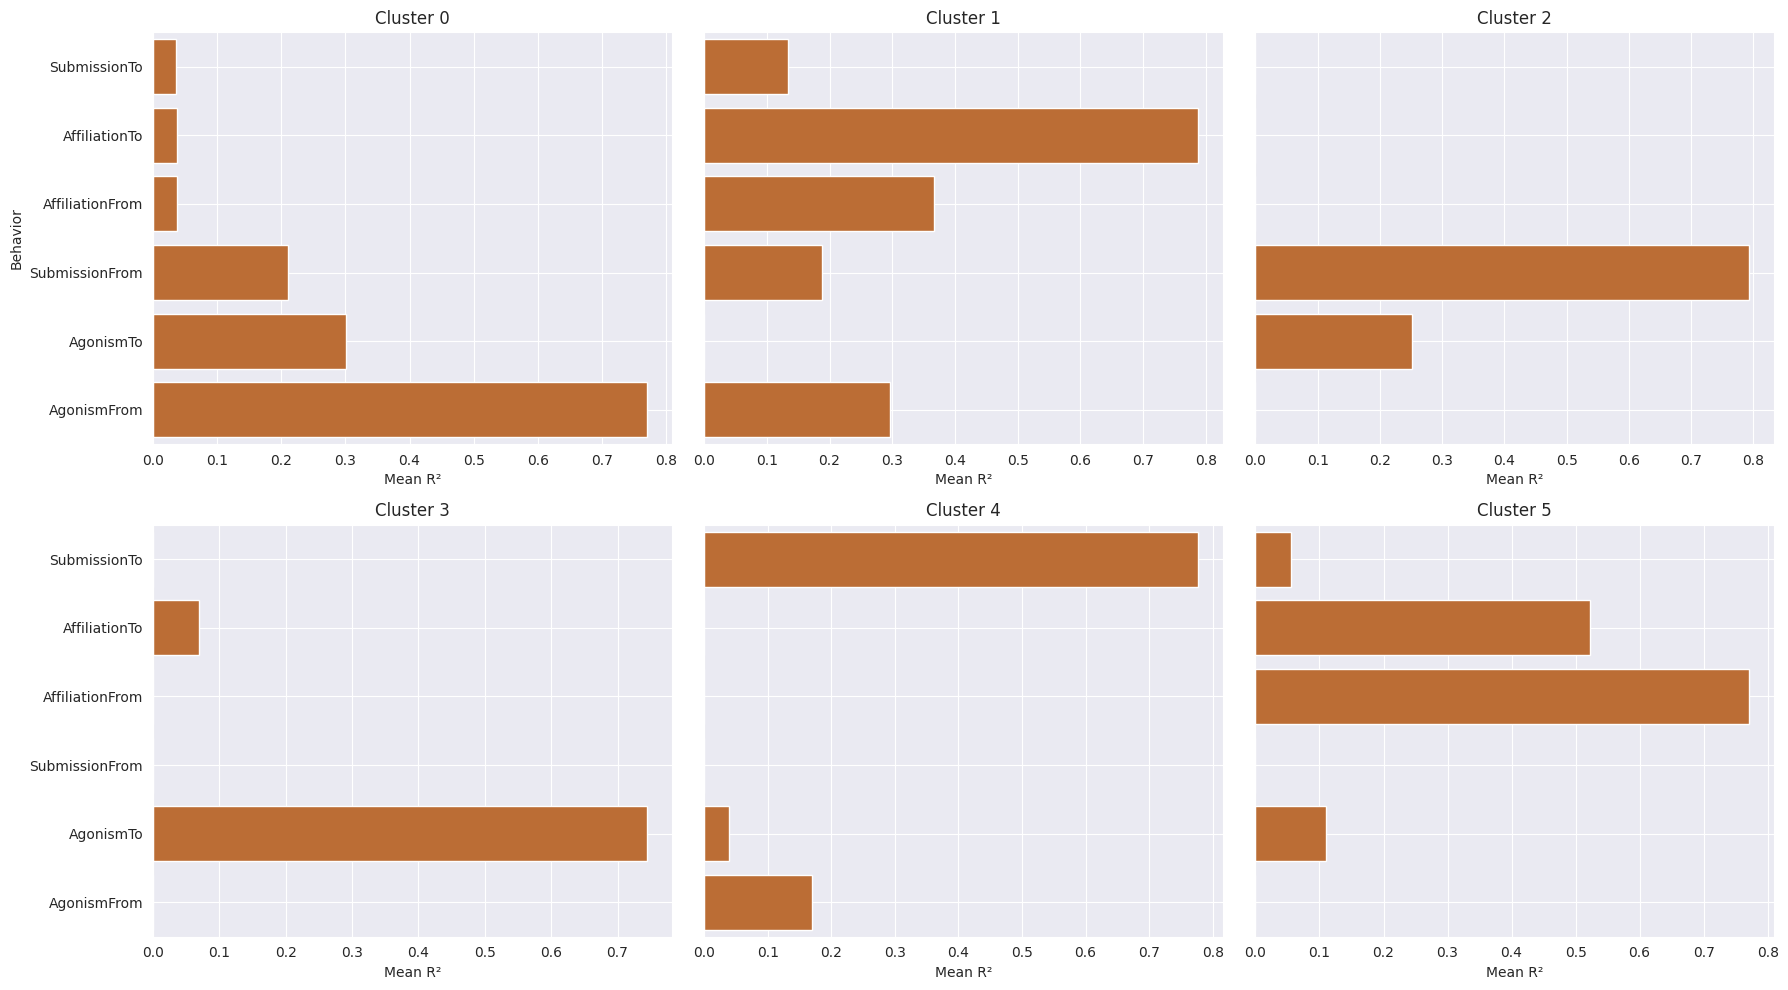

In [14]:
cluster_series = pd.Series(cluster_labels)
pivot_df_clustered = pivot_df.copy()
pivot_df_clustered['Cluster'] = cluster_labels
n_clusters = cluster_series.nunique()
# Figure setup
ncols = 3
nrows = (n_clusters + ncols - 1) // ncols  # 자동 계산

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), sharey=True)

axes = axes.flatten()
for i, cluster_id in enumerate(sorted(cluster_series.unique())):
    ax = axes[i] if n_clusters > 1 else axes

    cluster_df = pivot_df_clustered[pivot_df_clustered['Cluster'] == cluster_id].drop(columns='Cluster')
    mean_r2 = cluster_df.mean().sort_values(ascending=True)  # <- barh로 그릴거라서 ascending=True

    sns.barplot(x=mean_r2.values, y=mean_r2.index, ax=ax, color='chocolate')
    ax.set_title(f"Cluster {cluster_id}")
    ax.set_xlabel("Mean R²")
    if i == 0:
        ax.set_ylabel("Behavior")
    else:
        ax.set_ylabel("")
    ax.grid(True)

plt.tight_layout()
plt.show()

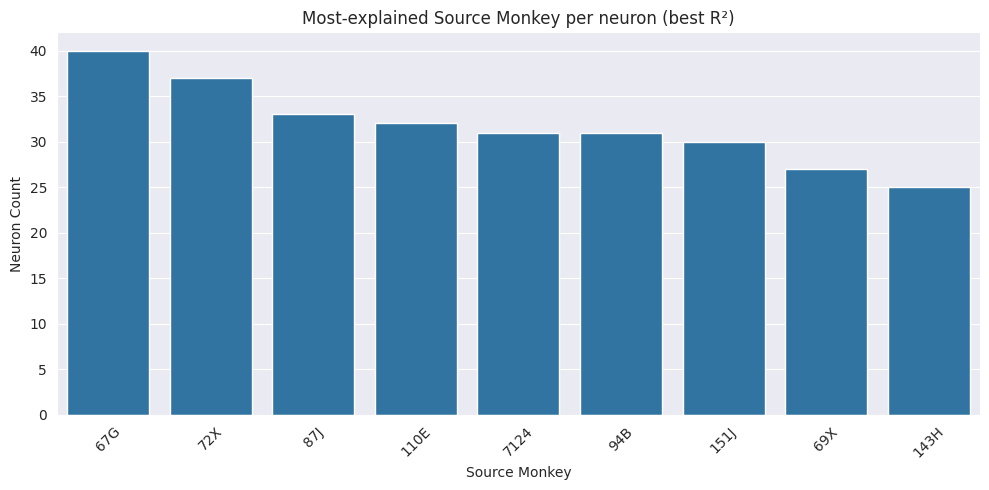

In [4]:
best_monkey_df = significant_results.sort_values('R-squared', ascending=False).drop_duplicates('NeuronID')
plt.figure(figsize=(10, 5))
sns.countplot(data=best_monkey_df, x='Source_Monkey', order=best_monkey_df['Source_Monkey'].value_counts().index)
plt.title("Most-explained Source Monkey per neuron (best R²)")
plt.xlabel("Source Monkey")
plt.ylabel("Neuron Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()